In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# Mount Google Drive if running on Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # Use Google Drive for data storage
    DATA_PATH = '/content/drive/MyDrive/data'
    print("Google Drive mounted. Data path set to:", DATA_PATH)
except (ImportError, ValueError, Exception) as e:
    # Use local directory if not on Colab OR if drive mount fails
    DATA_PATH = './data'
    print("Drive mount failed or not running on standard Colab.")
    print(f"Error: {e}")
    print("Data path set to:", DATA_PATH)
    print("Note: If using VS Code with Colab, enable 'Colab: Mount Drive' in settings to support drive.mount().")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted. Data path set to: /content/drive/MyDrive/data


In [4]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
# Hyperparameters
BATCH_SIZE = 128
EPOCHS = 30
LEARNING_RATE = 3e-4
PATCH_SIZE = 4
NUM_CLASSES = 10
IMAGE_SIZE = 32
CHANNELS = 3
EMBED_DIM = 256
NUM_HEADS = 8
DEPTH = 6
MLP_DIM = 512
DROP_RATE = 0.1

In [6]:
print(EPOCHS)

30


In [7]:
# Data preprocessing (Updated)
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats, inplace=True)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [8]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

100%|██████████| 170M/170M [03:49<00:00, 742kB/s] 


In [9]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### ViT components

In [10]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (img_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))

    def forward(self, x):
        B = x.size(0)
        x = self.proj(x)  # (B, E, H/P, W/P)
        x = x.flatten(2).transpose(1, 2)  # (B, N, E)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        return x

In [11]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, drop_rate):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.dropout = nn.Dropout(drop_rate)

    def forward(self, x):
        x = self.dropout(F.gelu(self.fc1(x)))
        x = self.dropout(self.fc2(x))
        return x


In [12]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, drop_rate):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=drop_rate, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_dim, drop_rate)

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

In [13]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, num_classes, embed_dim, depth, num_heads, mlp_dim, drop_rate):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.encoder = nn.Sequential(*[
            TransformerEncoderLayer(embed_dim, num_heads, mlp_dim, drop_rate)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.encoder(x)
        x = self.norm(x)
        cls_token = x[:, 0]
        return self.head(cls_token)


In [14]:
# Instantiate model
model = VisionTransformer(
    IMAGE_SIZE, PATCH_SIZE, CHANNELS, NUM_CLASSES,
    EMBED_DIM, DEPTH, NUM_HEADS, MLP_DIM, DROP_RATE
).to(device)

In [15]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)  # Changed to AdamW + Weight Decay
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)         # Added Scheduler

In [16]:
# Training loop
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


In [17]:
# Evaluation loop
def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
    return correct / len(loader.dataset)



In [18]:
# Training Loop
train_accuracies, test_accuracies = [], []

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    test_acc = evaluate(model, test_loader)
    
    # Update scheduler
    scheduler.step()
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

Epoch 1/30, Train Loss: 1.6784, Train Acc: 0.3859, Test Acc: 0.5059
Epoch 2/30, Train Loss: 1.3807, Train Acc: 0.5017, Test Acc: 0.5501
Epoch 3/30, Train Loss: 1.2595, Train Acc: 0.5441, Test Acc: 0.5972
Epoch 4/30, Train Loss: 1.1838, Train Acc: 0.5760, Test Acc: 0.6153
Epoch 5/30, Train Loss: 1.1194, Train Acc: 0.6001, Test Acc: 0.6323
Epoch 6/30, Train Loss: 1.0663, Train Acc: 0.6187, Test Acc: 0.6432
Epoch 7/30, Train Loss: 1.0271, Train Acc: 0.6322, Test Acc: 0.6635
Epoch 8/30, Train Loss: 0.9768, Train Acc: 0.6517, Test Acc: 0.6707
Epoch 9/30, Train Loss: 0.9383, Train Acc: 0.6638, Test Acc: 0.6933
Epoch 10/30, Train Loss: 0.9070, Train Acc: 0.6767, Test Acc: 0.6854
Epoch 11/30, Train Loss: 0.8728, Train Acc: 0.6888, Test Acc: 0.7075
Epoch 12/30, Train Loss: 0.8384, Train Acc: 0.7003, Test Acc: 0.7128
Epoch 13/30, Train Loss: 0.8120, Train Acc: 0.7105, Test Acc: 0.7263
Epoch 14/30, Train Loss: 0.7821, Train Acc: 0.7222, Test Acc: 0.7301
Epoch 15/30, Train Loss: 0.7509, Train Acc:

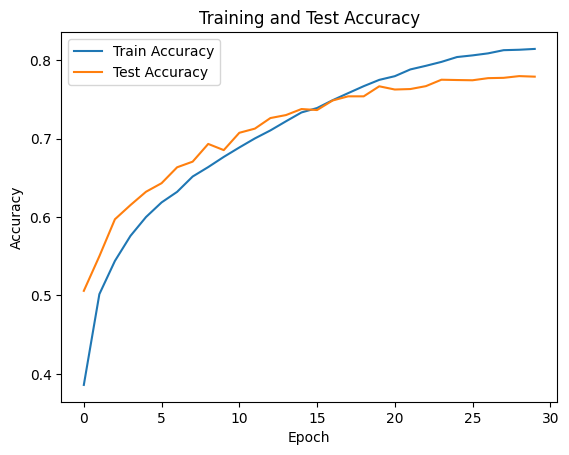

In [19]:
# Plot accuracy
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Test Accuracy')
plt.show()